In [1]:
from transformers import BertTokenizer, BertModel


c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# 리턴값 분석을 위한 출력 -SDPA 고속연산은 어텐션 가중치를 외부로 빼지 않음
model = BertModel.from_pretrained("bert-base-uncased", attn_implementation='eager') 

c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Playdata\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5520.65it/s]
[transformers] BertModel 

In [3]:
text = "The cat sat on the mat."
inputs = tokenizer(text, return_tensors='pt')
print(inputs)
# 모델 통과 및 어텐션 텐서 변환
outputs = model(**inputs, output_attentions=True)
# # 토큰화된 단어들 확인
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
print(f'추출된 토큰들 : {tokens}')

all_attentions = outputs.attentions
print(f'모델이 반환한 전체 레이어 개수 : {len(all_attentions)}')
print(f'첫 번째 레이어의 어텐션 텐서 크기 : {all_attentions[0].shape}')

{'input_ids': tensor([[  101,  1996,  4937,  2938,  2006,  1996, 13523,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}
추출된 토큰들 : ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '.', '[SEP]']
모델이 반환한 전체 레이어 개수 : 12
첫 번째 레이어의 어텐션 텐서 크기 : torch.Size([1, 12, 9, 9])


In [ ]:
# 첫 번째 레이어의 어텐션 텐서 크기 : torch.Size([1, 12, 9, 9])
# 1 배치사이즈(문장 1개)
# 12 multi-haed-attention의 개수(모델이서로다른 12개의 관점에서 문장을 분석)
# 9,9 : 문장의 토큰수가 9개(cls~ sep) 9개의단어가 서로서로 몇점을 주는지 나타내는 9x9 크기

2D 어텐션 맵 크기: (9, 9)
[안내] 셀을 실행하시면 세로축(특정 단어)이 가로축(다른 단어들)을 얼마나 강하게 쳐다보고 있는지 색상으로 나타낸 히트맵 이미지가 출력됩니다!


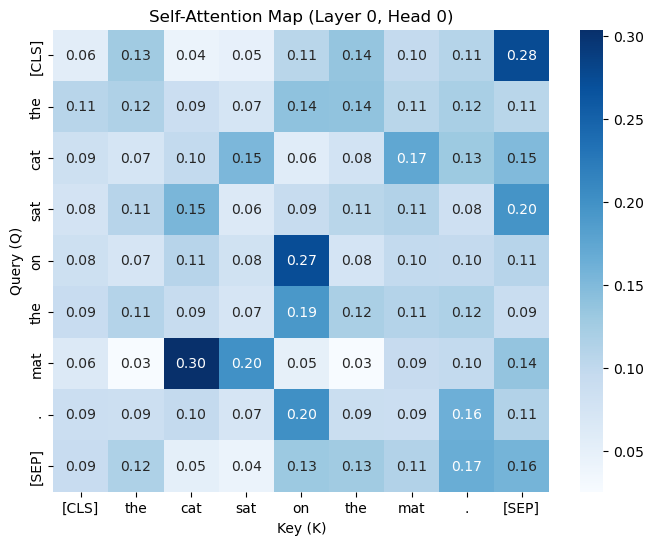

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
# 첫 번째 레이어(Layer 0), 첫 번째 배치(Batch 0), 첫 번째 헤드(Head 0)의 9x9 어텐션 표만 추출
# (도입 근거: 파이토치 텐서는 matplotlib가 읽지 못하므로 .detach().numpy()를 이용해 순수 배열로 변환합니다)
attn_matrix = all_attentions[0][0, 0, :, :].detach().numpy()
print("2D 어텐션 맵 크기:", attn_matrix.shape)

# 시각화 세팅
plt.figure(figsize=(8, 6))

# Seaborn의 heatmap을 이용하여 시각화 (색이 밝을수록/진할수록 가중치가 높음)
sns.heatmap(attn_matrix, 
            xticklabels=tokens, 
            yticklabels=tokens, 
            cmap='Blues', 
            annot=True, # 칸 안에 실제 숫자를 표시
            fmt=".2f")  # 숫자는 소수점 2자리까지만 표시

plt.title("Self-Attention Map (Layer 0, Head 0)")
plt.xlabel("Key (K)")
plt.ylabel("Query (Q)")
print("[안내] 셀을 실행하시면 세로축(특정 단어)이 가로축(다른 단어들)을 얼마나 강하게 쳐다보고 있는지 색상으로 나타낸 히트맵 이미지가 출력됩니다!")
plt.show()